<a href="https://colab.research.google.com/github/sally03915/2026-AI-Analysis-Lab/blob/main/AI-FlowTransformation/Step1-Math/basic007_%EC%8B%9C%EA%B7%B8%EB%AA%A8%EC%9D%B4%EB%93%9C%EB%AF%B8%EB%B6%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 👨‍🍳 데이터 분석 레스토랑: 시그모이드 함수의 비밀을 파헤치다

우리 레스토랑의 주방장(모델)은 요리(데이터)의 맛(결과)을 결정할 때, 재료의 양(입력값)이 전체 맛에 얼마나 영향을 미치는지 정확히 파악해야 합니다. 특히, 어떤 재료를 '조금 넣을지', '많이 넣을지'와 같이 **확률적으로 판단**해야 할 때가 있습니다. 이 역할을 해주는 것이 바로 **시그모이드(Sigmoid) 함수** 입니다.

시그모이드 함수는 어떤 값이든 0과 1 사이의 부드러운 값으로 변환하여, 마치 '확률 계산기'처럼 작동합니다. 하지만 셰프(신경망)가 레시피(모델 파라미터)를 개선하기 위해 재료의 '변화율', 즉 **'얼마나 조절해야 할지'를 알려주는 피드백 값, 미분(Derivative)** 을 알아야 할 때, 시그모이드는 특별한 특성을 보여줍니다.

이번 장에서는 시그모이드 함수가 어떻게 '확률'을 계산하고, 이 함수의 미분 값이 '재료 조절'에 어떻게 사용되는지, 그리고 그 미분이 가진 **'기울기 소실'이라는 치명적인 단점**이 무엇인지, 마치 레스토랑의 주방에서 요리의 비밀을 파헤치듯 자세히 들여다보겠습니다. 시그모이드의 수학적 의미부터 미분이 가진 '맛의 민감도', 그리고 그 그래프가 의미하는 바까지, 딥러닝 학습의 기초를 다지는 중요한 여정이 될 것입니다.

### 🚀 딥러닝, 우리 주변에서 언제 사용될까요? (실생활 예시)

딥러닝은 우리 주변의 정말 많은 곳에서 사용되고 있어요. 핵심은 **'데이터 속에서 패턴을 찾아내고', '미래를 예측하고', '최적의 결정을 내리는'** 일에 탁월하다는 점입니다.

*   **📱 이미지 인식:** 스마트폰으로 사진을 찍으면 자동으로 '사람', '강아지', '풍경' 등을 인식하죠? 이게 딥러닝이 하는 일입니다. 딥러닝 모델은 수많은 사진을 학습해서 새로운 사진이 들어왔을 때, '이 사진이 강아지일 확률이 90%야!'라고 알려줄 수 있습니다.

*   **🗣️ 음성 인식:** "헤이 구글" 또는 "시리야"처럼 말하면 기기가 알아듣고 반응하는 것도 딥러닝 덕분이에요. 우리가 말하는 소리의 파형에서 '어떤 단어인지' 패턴을 찾아내서 명령을 이해합니다.

*   **🌐 번역기:** 파파고나 구글 번역기가 외국어를 자연스럽게 번역해 주는 것도 딥러닝 모델이 수많은 언어 데이터를 학습했기 때문입니다. 문장의 의미 패턴을 파악하여 다른 언어로 바꾸어줍니다.

*   **🎬 추천 시스템:** 넷플릭스에서 '이 영화를 좋아할 것 같아요!'라고 추천해주고, 유튜브에서 내가 볼 만한 영상을 추천해주죠? 이것도 딥러닝이 내 취향과 행동 패턴을 학습해서 예측하는 겁니다.

*   **🚗 자율 주행 자동차:** 주변 사물(자동차, 사람, 표지판)을 인식하고, 앞으로 어떻게 움직여야 할지 끊임없이 판단하고 결정하는 데 딥러닝이 사용됩니다. 복잡한 도로 상황에서 가장 안전하고 효율적인 방법을 찾아냅니다.


<br/>
<br/>
<br/>

---  


<br/>
<br/>
<br/>



### 👨‍🍳 데이터 분석 레스토랑: 001. 시그모이드(Sigmoid) 함수

우리 레스토랑의 주방장(모델)이 어떤 재료(입력값)를 받았을 때, 이 재료를 요리에 **'얼마나 넣을지(확률)'** 또는 **'어떤 종류의 요리인지(이진 분류)'** 판단해야 한다고 상상해 봅시다. 시그모이드 함수는 이 판단을 **0과 1 사이의 부드러운 값**으로 만들어주는 특별한 저울과 같습니다.


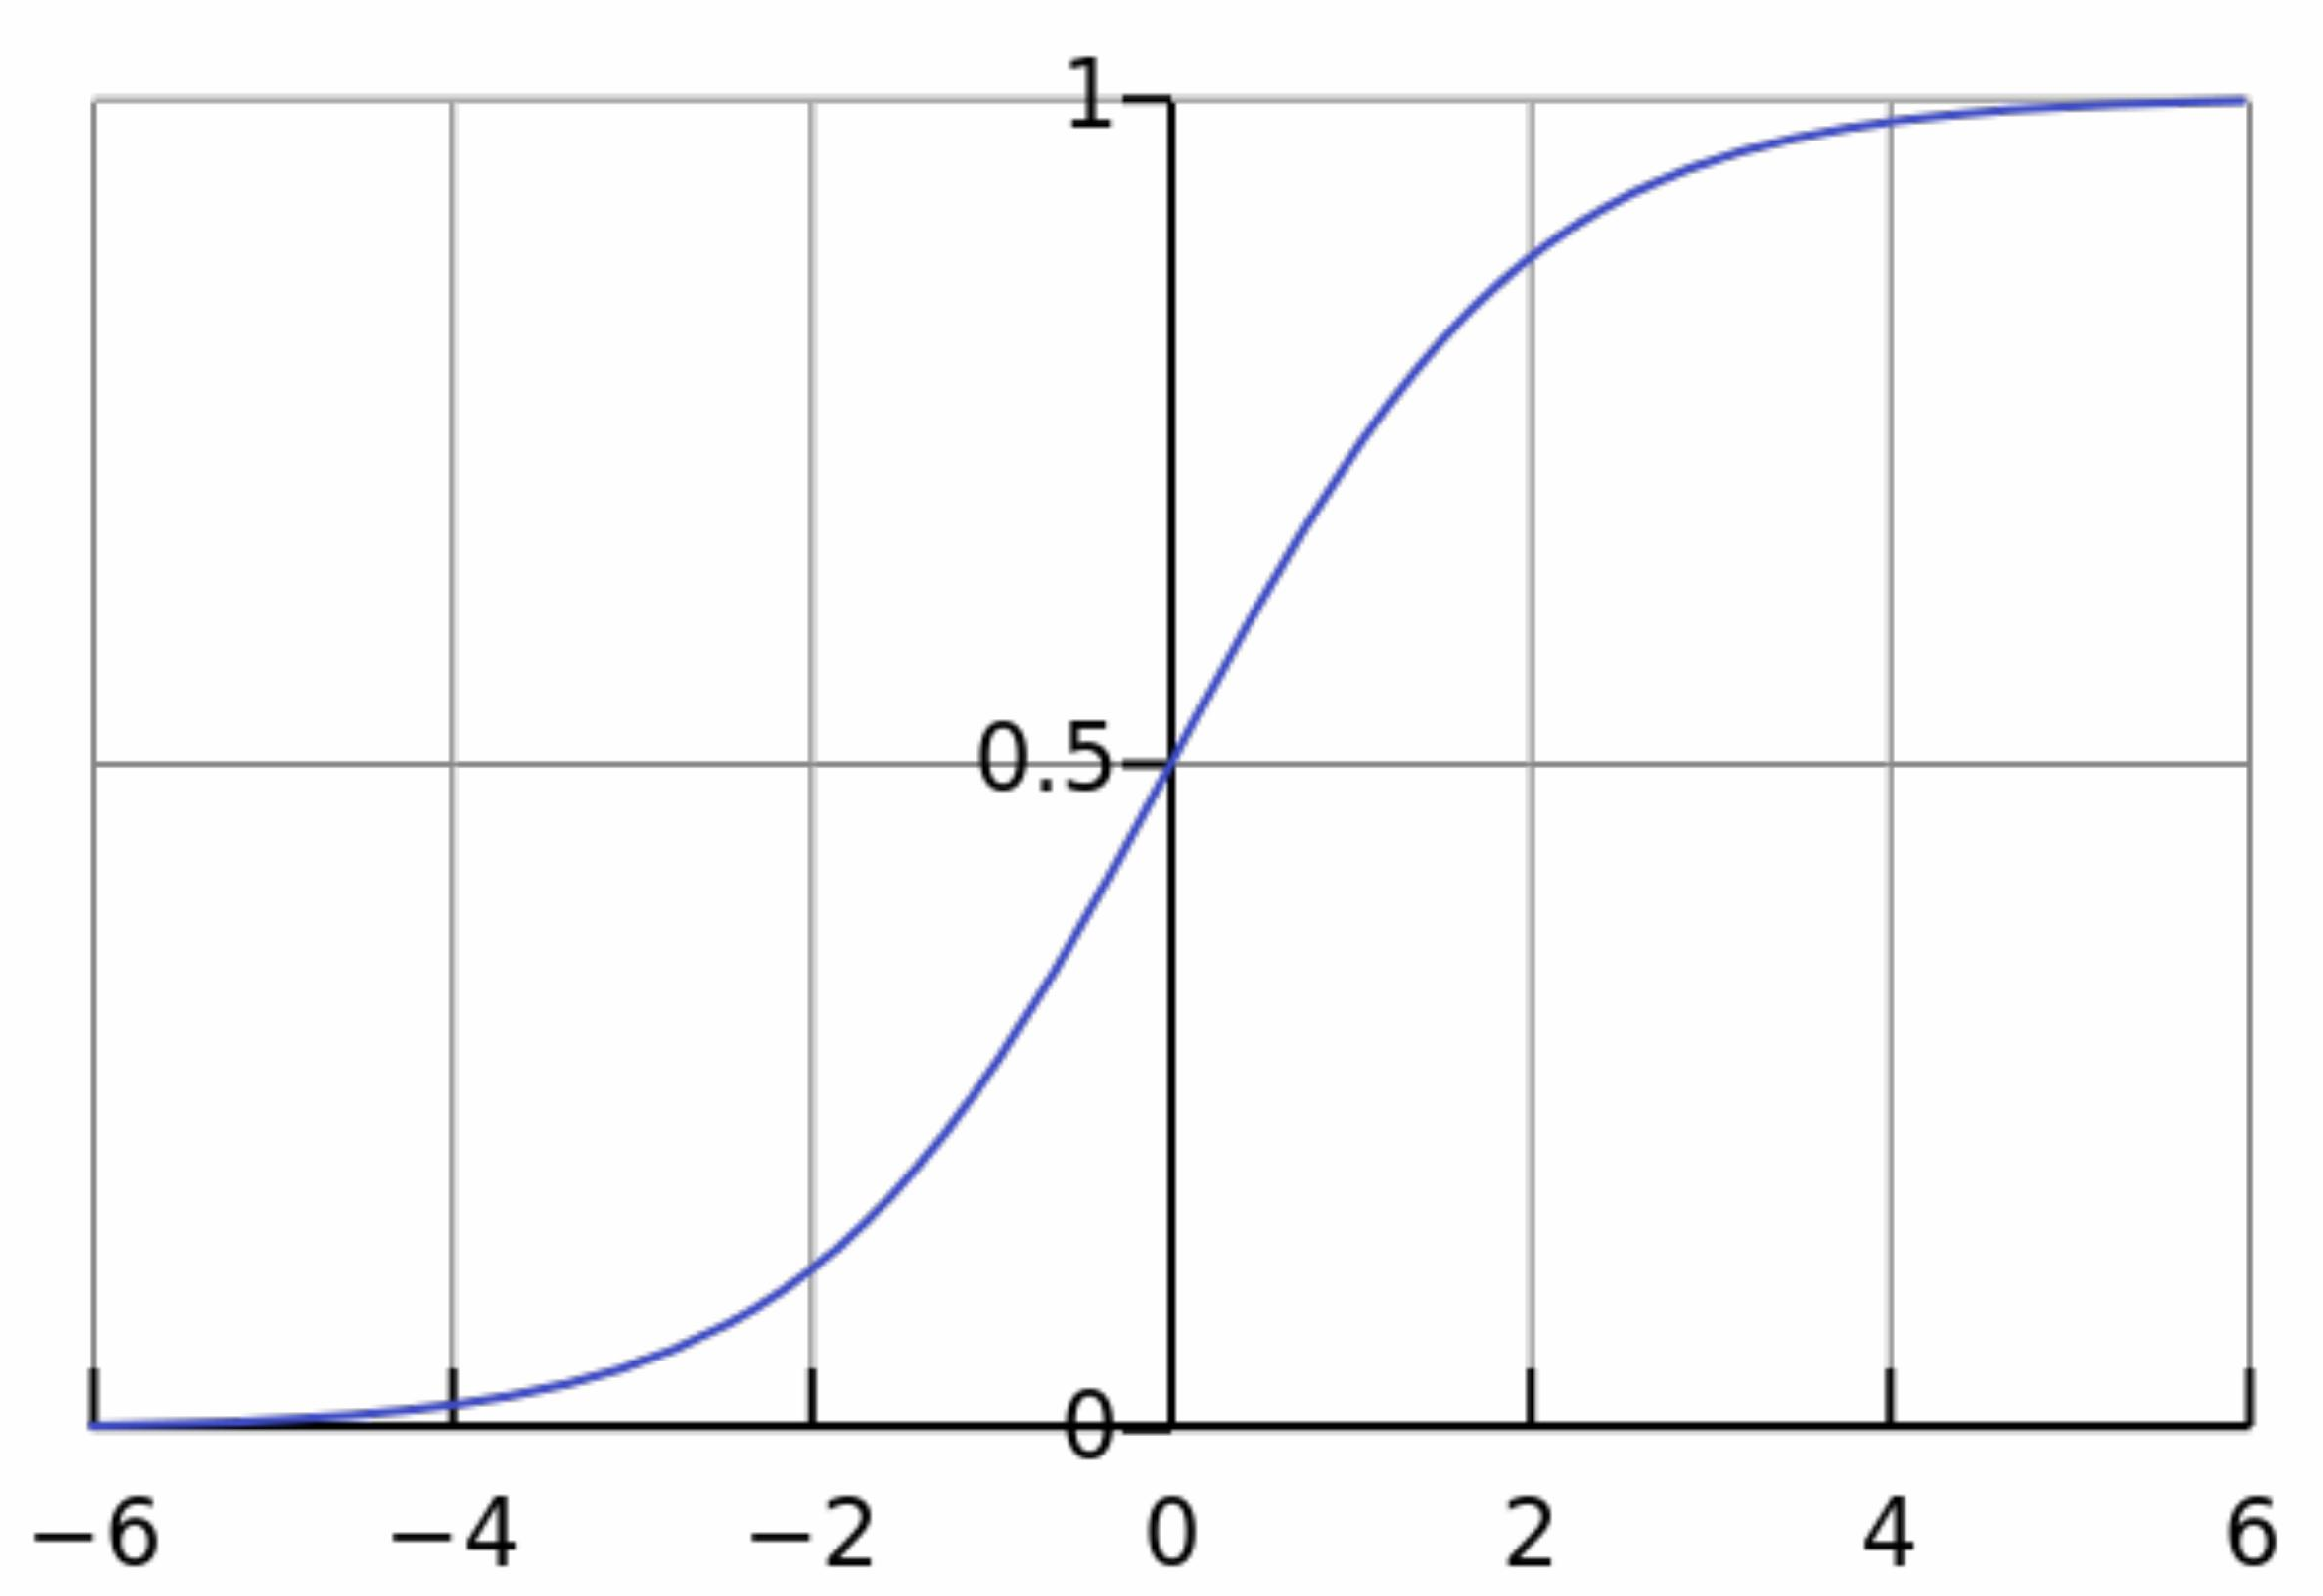



**수학적 의미:**
$$\sigma(x) = \frac{1}{1 + e^{-x}}, \quad \sigma(x) \in (0,1)$$
이 공식은 어떤 숫자 `x`를 넣어도 항상 0과 1 사이의 값으로 바꿔주는 마법의 계산기입니다.

**요리 비유 (생활 비유):**
"이 저울은 어떤 극단적인 재료의 양(입력값)이 들어와도 항상 0%에서 100% 사이의 **부드러운 비율(확률)** 로만 값을 내어줍니다. 마치 '온/오프' 스위치가 아니라 '점진적으로 조절되는 밸브'처럼요. 덕분에 셰프(모델)는 '이 재료를 70% 정도만 넣어야겠다'와 같이 섬세하게 판단할 수 있습니다."

**딥러닝 연결:**

🦍 **딥러닝에서의 역할 (1):**
딥러닝에서 시그모이드는 주로 **이진 분류 문제**에서 '이것일 확률이 70%야'처럼 예측값을 확률처럼 해석할 수 있게 해주는 '확률 번역기' 역할을 합니다. 예를 들어, '이 이미지는 고양이일 확률이 85%야'라고 말이죠.

🦍 **더 쉽게 풀어보는 딥러닝 예시 (2):**
모델이 어떤 정보가 '얼마나 중요한지'를 0%에서 100% 사이의 중요도로 알려주는 것과 같아요. 0%는 '전혀 안 중요해', 100%는 '아주 중요해!' 처럼요. 어떤 복잡한 상황이 와도 항상 깔끔하게 중요도를 퍼센트로 표현해줍니다.

**진짜진짜 쉬운 설명 👶:**
시그모이드는 마치 '예/아니오'를 '확실히 예/확실히 아니오'가 아니라 '70% 예, 30% 아니오'처럼 부드러운 확률로 말해주는 번역가 같아요. 어떤 숫자든 0과 1사이의 퍼센트로 바꿔주죠.

**🧮 파이썬으로 보는 쉬운 시그모이드 예시:**

#### 🚦 딥러닝 핵심 개념, '초보 운전사 AI' 비유로 이해하기

우리가 만드는 딥러닝 모델을 **'초보 운전사 인공지능(AI)'**이라고 생각해 봅시다. 이 AI는 처음에는 운전을 전혀 못 해요. 우리가 이 AI에게 운전을 가르쳐줘야 합니다.

**시그모이드 (Sigmoid): '우회전할 확률은 몇 %일까?' (확률 판단)**

*   **초보 운전사 AI의 고민:** 교차로에 도착했어요. 이때 AI는 '앞으로 가야 할까?', '좌회전할까?', '우회전할까?'를 결정해야 해요. 사람이 만든 내비게이션(데이터)을 보고 **'우회전할 확률이 80%네!'** 라고 판단합니다.
*   **시그모이드의 역할:** 시그모이드 함수는 바로 이렇게 복잡한 상황을 **0%에서 100% 사이의 '확률'**로 바꿔서 AI에게 판단 근거를 주는 도구입니다.
*   **핵심:** 시그모이드는 AI가 '예/아니오'처럼 딱 떨어지는 결정 대신, **'이럴 가능성이 몇 %다'** 라는 섬세한 판단을 할 수 있게 해줍니다. AI가 더 똑똑하고 유연하게 판단하도록 돕는 거죠.

In [ ]:
import numpy as np

def sigmoid_easy(x):
    # np.exp는 e의 x승을 계산해줍니다.
    return 1 / (1 + np.exp(-x))

print(f"입력 0일 때 시그모이드 값: {sigmoid_easy(0):.4f}") # 중간값은 0.5에 가까움
print(f"입력 5일 때 시그모이드 값: {sigmoid_easy(5):.4f}") # 양수일 때는 1에 가까움
print(f"입력 -5일 때 시그모이드 값: {sigmoid_easy(-5):.4f}") # 음수일 때는 0에 가까움


입력 0일 때 시그모이드 값: 0.5000
입력 5일 때 시그모이드 값: 0.9933
입력 -5일 때 시그모이드 값: 0.0067


#### 💡 확인 문제: 001. 시그모이드(Sigmoid) 함수

Q1. 시그모이드 함수의 출력값은 항상 어떤 범위 안에 있나요?

Q2. 시그모이드 함수는 주로 어떤 종류의 딥러닝 문제에서 '확률 번역기' 역할을 한다고 설명되었나요?

Q3. `sigmoid_easy(0)`의 값은 대략 얼마가 나오며, 이는 어떤 의미를 가지나요?

✅ **정답**

Q1. 0과 1 사이 (0보다 크고 1보다 작은 값)

Q2. 이진 분류 문제 (예: 고양이인지 아닌지)

Q3. 약 0.5가 나오며, 이는 '반반의 확률' 또는 '중간 값'을 의미합니다.


<br/>
<br/>
<br/>

---  


<br/>
<br/>
<br/>



### 👨‍🍳 데이터 분석 레스토랑: 002. 시그모이드 미분(Derivative)의 맛

주방장(모델)이 요리를 한 후, '음, 이 맛은 좀 더 달콤하게 해야겠어' 혹은 '이 재료는 좀 줄여야겠네' 하고 맛(오차)을 보고 레시피를 **조정(학습)**하는 과정이 필요합니다. 이때, 각 재료의 양을 얼마나 미세하게 조정해야 할지 알려주는 것이 바로 **미분 값, 즉 '기울기'** 입니다.

시그모이드 함수의 미분은 특별한 점이 있습니다. 자기 자신이 만들어내는 값으로 자신의 변화량을 결정한다는 것이죠.




**수학적 의미:**
$$\frac{d}{dx}\sigma(x) = \sigma(x)(1 - \sigma(x))$$
놀랍게도 시그모이드 함수의 미분은 자기 자신($\sigma(x)$)과 $(1 - \sigma(x))$를 곱한 값이라는 아주 간단한 형태로 나옵니다. 이 간단한 공식이 딥러닝 학습에 큰 영향을 줍니다.

**요리 비유 (생활 비유):**
"이 시그모이드 미분은 마치 '자기 맛을 스스로 평가하여 다음 조리법을 결정하는 재료'와 같습니다. '지금 단맛이 70%니까, 다음에는 단맛을 70%의 30%(1-70%)만큼 조절해야겠어'라고 스스로 피드백을 주는 것이죠. 즉, 현재 상태를 보고 다음 행동을 얼마나 바꿀지 결정하는 기준이 됩니다."

**딥러닝 연결:**
딥러닝의 학습 과정인 **역전파(backpropagation)** 에서는 이 미분 값을 사용하여 신경망의 가중치를 업데이트합니다. 시그모이드 미분은 계산이 매우 간단하여 역전파 계산을 효율적으로 만들어줍니다. 하지만 이 '자기 피드백' 방식은 재료의 양(입력값)이 극단적일 때(매우 많거나 적을 때)는 피드백(기울기)이 거의 0이 되어, 주방장(모델)이 더 이상 레시피를 조정하지 못하는 **'기울기 소실 문제(Vanishing Gradient Problem)'** 를 일으킵니다.

🦍 **딥러닝에서의 역할 (1):**
모델이 예측을 틀렸을 때, 각 뉴런의 '중요도'를 얼마나 바꿔야 할지 알려주는 신호등 역할을 합니다. 이 기울기 값이 크면 '크게 바꿔!', 작으면 '조금만 바꿔!'라고 지시해서 모델이 점점 더 똑똑해지게 만듭니다.

🦍 **더 쉽게 풀어보는 딥러닝 예시 (2):**
요리사가 '이 재료를 1g 더 넣었을 때 맛이 얼마나 변할까?'를 미리 예측하는 공식과 같아요. 그래서 다음번에 이 재료를 얼마나 넣을지 현명하게 결정할 수 있죠. **시그모이드 미분은 '지금 이 재료를 조금 바꿨을 때, 요리 전체의 맛이 얼마나 달라질까?'를 알려주는 민감도 측정계**라고 할 수 있습니다.

**진짜진짜 쉬운 설명 👶:**
시그모이드 미분은 '지금 이 상황에서 얼마나 조심스럽게 움직여야 할까?'를 알려주는 속도계 같아요. 중앙에서는 '빨리 움직여도 돼!' 하고, 양쪽 끝에서는 '아주 조금만 움직여야 해, 아니면 망가져!'라고 속도를 조절하라고 하죠.

**🧮 파이썬으로 보는 쉬운 시그모이드 미분 예시:**

#### 🚦 딥러닝 핵심 개념, '초보 운전사 AI' 비유로 이해하기 (계속)

**미분 (Derivative): '핸들을 어느 방향으로, 얼마나 돌려야 할까?' (피드백과 조절량)**

*   **초보 운전사 AI의 실수:** AI가 운전을 하다가 차선 중앙에서 약간 벗어났어요! '어떤 방향으로 핸들을 돌려야 다시 중앙으로 올 수 있을까?', '핸들을 조금만 돌릴까, 아니면 많이 돌릴까?' 이 고민을 합니다.
*   **미분의 역할:** 이때 미분이 등장합니다. 미분은 현재 상태(차선 중앙에서 벗어난 정도)를 보고 **'오른쪽으로 5도만 돌리면 돼!', '아니야, 너무 많이 벗어났으니 왼쪽으로 20도 돌려야 해!'** 처럼 **정확한 '방향'과 '조절량(기울기)'을 알려주는 내비게이션 역할**을 합니다.
*   **핵심:** 미분은 AI가 **실수(오차)를 했을 때, 어떻게 그 실수를 고쳐야 할지(가중치를 업데이트할지) 알려주는 가장 중요한 정보**입니다. AI가 점점 더 능숙한 운전사가 되도록 도와주는 핵심 피드백이죠.

In [ ]:
import numpy as np

def sigmoid_easy(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative_easy(x):
    # 미분 공식: 시그모이드 값 * (1 - 시그모이드 값)
    s = sigmoid_easy(x)
    return s * (1 - s)

print(f"입력 0일 때 시그모이드 미분 값: {sigmoid_derivative_easy(0):.4f}") # 기울기가 가장 큼 (약 0.25)
print(f"입력 5일 때 시그모이드 미분 값: {sigmoid_derivative_easy(5):.4f}") # 기울기가 0에 가까움
print(f"입력 -5일 때 시그모이드 미분 값: {sigmoid_derivative_easy(-5):.4f}") # 기울기가 0에 가까움


입력 0일 때 시그모이드 미분 값: 0.2500
입력 5일 때 시그모이드 미분 값: 0.0066
입력 -5일 때 시그모이드 미분 값: 0.0066


#### 💡 확인 문제: 002. 시그모이드 미분(Derivative)의 맛

Q1. 시그모이드 함수의 미분은 자기 자신($\sigma(x)$)과 어떤 값을 곱하는 형태로 나타나나요?

Q2. 딥러닝 학습 과정에서 시그모이드 미분 값은 주로 무엇을 업데이트하는 데 사용되나요?

Q3. 미분 값이 0에 가까워지는 현상이 너무 심할 때 발생하는 딥러닝의 문제점은 무엇인가요?

✅ **정답**

Q1. $ (1 - \sigma(x)) $ (즉, 시그모이드 값과 1에서 시그모이드 값을 뺀 값을 곱함)

Q2. 신경망의 가중치 (모델의 레시피를 조정)

Q3. 기울기 소실(Vanishing Gradient) 문제


<br/>
<br/>
<br/>




---


<br/>
<br/>
<br/>



### 👨‍🍳 데이터 분석 레스토랑: 003. 시그모이드 미분 과정: 레시피의 숨은 비밀

우리는 앞서 시그모이드 함수의 미분 결과가 바로 `$\sigma(x)(1-\sigma(x))$`라는 아주 간단한 형태로 나오는 것을 보았습니다. 겉보기에는 복잡한 수학 공식처럼 보이지만, **'시그모이드 자기 자신'과 '1에서 시그모이드를 뺀 값'을 곱하는 것**이라는, 놀랍도록 간단한 형태로 정리됩니다. 마치 복잡한 재료를 썼는데, 핵심은 딱 두 가지 재료의 조합으로 맛을 결정하는 것과 같습니다.

이 과정은 마치 셰프가 '겉보기엔 복잡한 요리도 사실 몇 가지 핵심 원리만 알면 간단하게 만들 수 있다'고 알려주는 것과 같습니다. **딥러닝에서는 이 복잡한 미분 과정을 컴퓨터가 '자동으로' 해주기 때문에, 우리는 이 '숨은 비밀'이 무엇을 의미하는지에 집중하면 됩니다.**

**진짜진짜 쉬운 설명 👶:**
시그모이드 함수의 미분은 '시그모이드가 어떤 값을 내놓았는지'와 '그 값이 1에서 얼마나 떨어져 있는지'를 곱하는 것만으로 계산할 수 있어요! 마치 요리사가 자기 요리의 상태를 보고, 다음엔 얼마나 더 넣거나 뺄지 스스로 피드백을 주는 것처럼요. 컴퓨터는 이걸 알아서 척척 해준답니다!



**수학적 의미 (개념 설명):**

시그모이드 함수는 사실 몇 가지 기본 함수들이 **합쳐져 있는(합성 함수)** 형태입니다. 수학에서는 이런 합성 함수를 미분할 때 **'연쇄 법칙(Chain Rule)'** 이라는 규칙을 사용합니다. 이 법칙은 복잡한 함수도 여러 개의 간단한 함수로 나누어 하나씩 미분한 다음 다시 합치는 원리예요.

이 미분 과정 자체가 겉보기에는 복잡한 수학 공식들로 이루어져 있지만, **결론적으로 시그모이드 함수의 미분은 자기 자신(`\(\sigma(x)\)`)과 `\((1 - \sigma(x))\)`를 곱한 아주 간단한 공식으로 표현된다는 점이 가장 중요합니다.** 마치 긴 길을 돌고 돌아왔지만, 결국 가장 가까운 지름길을 찾은 것과 같아요. 우리는 매번 이 과정을 손으로 계산할 필요 없이, 이 '숨은 비밀'의 결과를 바로 활용할 수 있습니다.

**요리 비유 (생활 비유):**
"이 미분 과정은 셰프의 비법 레시피를 단계별로 해체하여 핵심 원리를 파악하는 것과 같습니다. 복잡해 보이는 요리 과정(미분)도 결국은 재료 본연의 특성(시그모이드 함수 자신)을 활용한 간단한 조작으로 귀결된다는 것을 보여줍니다. 마치 컴퓨터가 뚝딱하고 복잡한 계산을 해주는 것처럼요!"

**딥러닝 연결:**

딥러닝에서는 **'자동미분(Automatic Differentiation)' 프레임워크**가 이 복잡한 미분 과정을 대신 처리해 줍니다. 우리는 `\(\sigma(x)(1-\sigma(x))\)`라는 간단한 공식이 나오기까지의 복잡한 수학적 유도 과정을 일일이 알 필요 없이, **'아, 딥러닝 라이브러리가 알아서 이 값을 계산해주는구나!'** 하고 이해할 수 있습니다.

🦍 **딥러닝에서의 역할 (1):**
신경망 안에서 복잡하게 얽힌 모든 '재료들의 관계(함수)'를 하나하나 풀어내어, 최종적으로 목표한 맛(결과)과의 차이를 줄이는 데 필요한 '각 재료의 정확한 조절량'을 자동으로 계산하는 방법입니다. 우리는 이 계산을 직접 할 필요 없이, 컴퓨터가 해주는 결과를 바탕으로 모델을 학습시킵니다.

🦍 **더 쉽게 풀어보는 딥러닝 예시 (2):**
아주 복잡한 요리 레시피가 있을 때, '이 재료는 저 재료와 연결되어 있고, 저 재료는 또 다른 재료에 영향을 미치네?' 하면서 모든 관계를 파악하고, 결국 '어떤 재료를 얼마나 조절해야 전체 맛이 가장 좋아질까?'를 찾아내는 똑똑한 비서와 같습니다. **우리가 재료별로 계산할 필요 없이 비서가 알려준 대로만 따라 하면 됩니다.**

**진짜진짜 쉬운 설명 👶:**
복잡한 퍼즐을 풀 때, 한 번에 다 풀려 하지 않고 '조각별로 나눠서 풀고, 나중에 다시 합치면' 쉽게 풀리는 것과 같아요. 시그모이드 미분도 어려운 계산을 여러 작은 단계로 나누어 풀면 쉬워지는데, **이 과정을 우리가 아니라 똑똑한 컴퓨터가 다 해줘요!**

**🧮 파이썬으로 미분 공식을 확인하는 쉬운 예시:**

In [ ]:
import numpy as np

def sigmoid_easy(x):
    return 1 / (1 + np.exp(-x))

# 직접 계산한 미분 공식
def sigmoid_derivative_formula(x):
    s = sigmoid_easy(x)
    return s * (1 - s)

# Chain Rule을 이용한 미분 중간 과정 (수학적 의미의 결과와 동일함을 보여줌)
def sigmoid_derivative_chain_rule(x):
    # (1+e^-x)^-1 미분 = -1 * (1+e^-x)^-2 * (-e^-x)
    term1 = -1
    term2 = (1 + np.exp(-x))**(-2)
    term3 = -np.exp(-x)
    return term1 * term2 * term3

input_value = 0.5
print(f"입력 {input_value}일 때, 유도된 미분 공식 값: {sigmoid_derivative_formula(input_value):.4f}")
print(f"입력 {input_value}일 때, 체인 룰 미분 과정 값: {sigmoid_derivative_chain_rule(input_value):.4f}")
print("두 값이 거의 같음을 확인할 수 있습니다.")


입력 0.5일 때, 유도된 미분 공식 값: 0.2350
입력 0.5일 때, 체인 룰 미분 과정 값: 0.2350
두 값이 거의 같음을 확인할 수 있습니다.


#### 💡 확인 문제: 003. 시그모이드 미분 과정: 레시피의 숨은 비밀

Q1. 시그모이드처럼 몇 가지 기본 함수들이 합쳐진 형태의 함수를 미분할 때 사용하는 수학적 규칙은 무엇인가요?

Q2. 딥러닝에서 복잡한 미분 과정을 대신 처리해주는 기술의 이름은 무엇인가요?

Q3. 수학적 유도 과정은 복잡하지만, 시그모이드 미분 공식의 최종 형태가 가지는 특징은 무엇인가요?

✅ **정답**

Q1. 연쇄 법칙(Chain Rule)

Q2. 자동미분(Automatic Differentiation) 프레임워크

Q3. 자기 자신($\sigma(x)$)과 $(1-\sigma(x))$를 곱하는 아주 간단한 형태



<br/>
<br/>
<br/>

---  


<br/>
<br/>
<br/>




### 👨‍🍳 데이터 분석 레스토랑: 004. 시그모이드 미분 그래프: 맛의 민감도 지도

주방장(모델)이 요리의 맛(오차)을 조절할 때, 어떤 재료(입력)에 가장 민감하게 반응하고, 어떤 재료에는 둔감하게 반응하는지를 한눈에 볼 수 있는 '맛의 민감도 지도'가 있다면 어떨까요? 시그모이드 함수의 미분 그래프가 바로 그런 역할을 합니다.

이 그래프는 시그모이드 함수의 기울기 값을 시각화한 것으로, x축은 입력값, y축은 해당 입력값에서의 기울기를 나타냅니다.




**수학적 의미:**
*   **최대값:** 약 0.25 (x=0, 시그모이드 함수의 중심) – 이 지점에서 시그모이드가 가장 민감하게 반응하고, 변화량이 가장 큽니다.
*   **양 끝으로 갈수록 기울기:** 0에 수렴 (입력값이 양수 또는 음수 방향으로 커질수록) – 이 지점에서는 시그모이드가 둔감해져서 변화량이 거의 없습니다.

**요리 비유 (생활 비유):**
"이 '맛의 민감도 지도'를 보면 주방장은 재료의 양(입력값)이 **중간 정도일 때(x=0 근처)** 는 아주 작은 변화에도 맛(기울기)이 크게 변한다는 것을 알 수 있습니다. 하지만 재료의 양이 **너무 많거나(큰 양수) 너무 적을 때(큰 음수)**는 아무리 재료를 더 넣거나 빼도 맛의 변화(기울기)가 거의 느껴지지 않아 '이 요리는 더 이상 고칠 수 없어!' 하고 포기하게 되는 상황과 같습니다."

**딥러닝 연결:**
이 그래프는 딥러닝에서 시그모이드가 일으키는 **'기울기 소실 문제'** 를 가장 직관적으로 보여줍니다. 신경망이 학습할 때, 입력값이 시그모이드의 '둔감한 영역'(그래프의 양 끝)에 떨어지면 기울기가 거의 0이 되어 가중치 업데이트가 미미해지고, 결국 모델은 더 이상 학습하지 못하게 됩니다. 이는 학습 속도 저하를 넘어 아예 학습이 멈추는 결과를 초래할 수 있습니다. **쉽게 말해, 학습이 '벽에 부딪혀' 더 이상 똑똑해지지 않는 상태가 되는 것이죠.**

🦍 **딥러닝에서의 역할 (1):**
모델이 '학습에 얼마나 열심히 귀 기울여야 하는지'를 알려주는 지표입니다. 그래프의 봉우리가 높으면 '여기에 집중해!', 바닥에 가까우면 '여기는 무시해도 돼!'라고 말하는 것과 같습니다. 이 그래프를 통해 **어떤 입력값 범위에서 모델이 가장 효율적으로 학습할 수 있는지**를 알 수 있습니다.

🦍 **더 쉽게 풀어보는 딥러닝 예시 (2):**
어떤 재료가 '맛 변화'에 가장 큰 영향을 주는지 시각적으로 보여주는 '영향력 지도'와 같아요. 중심부에 가까운 재료는 조금만 바꿔도 맛이 확 달라지고, 너무 많거나 적은 재료는 바꿔도 티가 안 나는 거죠. **그래서 딥러닝 모델은 이 '영향력 지도'의 가운데 부분을 잘 활용해야 학습을 성공적으로 할 수 있습니다.**

**진짜진짜 쉬운 설명 👶:**
이 그래프는 시그모이드가 '언제 제일 말을 잘 듣고, 언제 말을 안 듣는지'를 보여주는 지도예요. 가운데 '꼭대기'에서는 조금만 건드려도 크게 반응하지만, 양쪽 '바닥'에서는 아무리 건드려도 반응이 없는 잠자는 거인 같죠. **모델은 이 잠자는 거인을 깨우기가 아주 어렵기 때문에, 학습이 멈춰버릴 수 있습니다.**

**🧮 파이썬으로 민감도 변화 확인하는 쉬운 예시:**

In [ ]:
import numpy as np

def sigmoid_easy(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative_easy(x):
    s = sigmoid_easy(x)
    return s * (1 - s)

# 입력값에 따른 기울기(민감도) 변화를 확인합니다.
print(f"입력 0 (중간)일 때 기울기: {sigmoid_derivative_easy(0):.4f}")
print(f"입력 1 (약간 벗어남)일 때 기울기: {sigmoid_derivative_easy(1):.4f}")
print(f"입력 5 (많이 벗어남)일 때 기울기: {sigmoid_derivative_easy(5):.4f}")
print(f"입력 10 (극단적)일 때 기울기: {sigmoid_derivative_easy(10):.4f}")

print("입력값이 0에서 멀어질수록 기울기가 빠르게 0에 가까워지는 것을 볼 수 있습니다.")


입력 0 (중간)일 때 기울기: 0.2500
입력 1 (약간 벗어남)일 때 기울기: 0.1966
입력 5 (많이 벗어남)일 때 기울기: 0.0066
입력 10 (극단적)일 때 기울기: 0.0000
입력값이 0에서 멀어질수록 기울기가 빠르게 0에 가까워지는 것을 볼 수 있습니다.


#### 💡 확인 문제: 004. 시그모이드 미분 그래프: 맛의 민감도 지도

Q1. 시그모이드 미분 그래프에서 기울기(민감도)가 가장 높은 지점의 x값은 무엇인가요?

Q2. 입력값(x)이 0에서 멀어질수록 미분 값(기울기)은 어떻게 변하나요?

Q3. 미분 그래프의 양 끝이 0에 수렴하는 현상이 딥러닝 학습에 미치는 부정적인 영향은 무엇인가요?

✅ **정답**

Q1. x=0

Q2. 0에 수렴하여 매우 작아집니다.

Q3. 기울기 소실(Vanishing Gradient) 문제로 인해 학습이 느려지거나 멈춥니다.



<br/>
<br/>
<br/>

---  


<br/>
<br/>
<br/>





### 👨‍🍳 데이터 분석 레스토랑: 005. 시그모이드: 완벽한 맛을 찾기 위한 또 다른 시작

우리는 지금까지 시그모이드 함수가 어떻게 입력값을 0과 1 사이의 확률로 변환하는지, 그리고 그 미분 값이 학습에 어떻게 사용되는지를 살펴보았습니다. 시그모이드는 초기 딥러닝 모델에서 중요한 역할을 했지만, '기울기 소실'이라는 치명적인 단점을 가지고 있습니다.




**요리 비유 (생활 비유):**
"시그모이드는 재료의 양을 부드러운 비율로 조절하는 훌륭한 저울이지만, 너무 극단적인 재료에는 '맛을 조절하는 피드백'이 거의 오지 않는 한계가 있습니다. 마치 셰프가 중간 맛은 잘 잡아내지만, 너무 짜거나 너무 싱거운 요리에는 어떤 재료를 넣어도 변화를 느끼지 못해 개선하기 힘든 상황과 같습니다. **이런 요리는 결국 포기하고 새로운 방법을 찾아야겠죠?**"

**딥러닝 연결:**
시그모이드 함수는 뉴런의 활성화 여부를 결정하고 출력값을 특정 범위(0~1)로 압축하는 데 유용하지만, 특히 **심층 신경망(Deep Neural Networks)**에서는 다음과 같은 문제를 야기합니다.

1.  **기울기 소실 (Vanishing Gradient):** 미분 그래프에서 보았듯이, 입력값이 일정 범위를 벗어나면 기울기가 0에 가까워져 학습이 매우 느려지거나 멈춥니다. **이는 딥러닝 모델이 아무리 많은 데이터를 봐도 더 이상 똑똑해지지 않는 상태를 의미합니다.**
2.  **Zero-Centered Output Not Guaranteed:** 시그모이드의 출력은 항상 양수이므로, 다음 레이어의 입력이 항상 양수가 되어 학습 효율을 떨어뜨릴 수 있습니다 (Optimization issues). (이 부분은 '출력값이 한쪽으로만 치우쳐 있어서 모델이 학습할 때 좀 더 비효율적일 수 있다' 정도로 가볍게 설명하고 넘어갑니다)

이러한 단점들 때문에, 오늘날 대부분의 심층 신경망에서는 시그모이드 대신 **ReLU(Rectified Linear Unit)**와 그 변형들(Leaky ReLU, PReLU, ELU 등)과 같은 다른 활성화 함수들이 주로 사용됩니다. 이들은 '기울기 소실' 문제를 완화하고 학습 속도 저하를 가속화하는 데 크게 기여합니다.

따라서 시그모이드는 딥러닝 역사상 중요한 이정표이지만, 완벽한 맛(모델 성능)을 찾기 위한 여정에서 새로운 활성화 함수들을 탐색하는 '또 다른 시작'을 알리는 계기가 되었습니다.

🦍 **딥러닝에서의 역할 (1):**
시그모이드는 딥러닝 초기에 중요한 역할을 했지만, 너무 깊은 신경망에서는 '기울기 소실' 때문에 학습이 거의 불가능해지는 한계가 드러났습니다. 마치 너무 긴 파이프를 통해 물을 흘려보내면 끝에서는 물이 거의 나오지 않아 동력을 잃어버리는 것과 비슷하죠. **그래서 우리는 더 효과적으로 동력을 전달하는 다른 파이프(활성화 함수)를 찾게 되었습니다.**

🦍 **더 쉽게 풀어보는 딥러닝 예시 (2):**
모델이 깊은 숲 속에서 길을 찾아야 하는데, 시그모이드를 쓰면 너무 희미한 발자국만 남겨서 길을 잃기 쉬웠어요. 그래서 더 선명하고 뚜렷한 발자국을 남기는 '새로운 길잡이(활성화 함수)'들이 필요하게 된 거죠. **새로운 길잡이 덕분에 모델은 더 쉽게 길을 찾고 학습할 수 있게 되었습니다.**

**진짜진짜 쉬운 설명 👶:**
시그모이드는 오래된 라디오 같아요. 잘 들릴 때도 있지만, 멀리 있는 소식(정보)은 너무 작게 들려서 무슨 말인지 알 수 없게 되죠. 그래서 우리는 더 잘 들리는 '새로운 라디오(활성화 함수)'를 찾아야 했어요! **새 라디오는 멀리 있는 소식도 선명하게 들려줘서 딥러닝 모델이 훨씬 더 많은 것을 배울 수 있도록 도와줍니다.**

**🧮 파이썬으로 보는 기울기 소실 문제 예시:**

#### 🚦 딥러닝 핵심 개념, '초보 운전사 AI' 비유로 이해하기 (마무리)

**기울기 소실 (Vanishing Gradient): '핸들이 잠겨서 안 돌아가요!' (학습 정체)**

*   **초보 운전사 AI의 난관:** AI가 고속도로를 달리는데, 핸들이 거의 끝까지 돌아가 있는 상황(시그모이드 함수의 양 끝 영역)이 발생했어요. AI는 핸들을 돌리려고 하는데, **핸들이 너무 뻑뻑해서(미분 값이 너무 작아서) 거의 돌아가지 않는 거예요!**
*   **결과:** 핸들이 잠겨서 안 돌아가니, AI는 차선 중앙으로 돌아올 수 없고, 아무리 노력해도 운전 실력이 늘지 않습니다. 이것이 바로 **'기울기 소실'**입니다. 모델이 더 이상 배우지 못하고 멈춰버리는 거죠.
*   **핵심:** 기울기 소실은 AI가 **'어떤 것을 배워야 할지' 신호를 받지 못해서 더 이상 똑똑해지지 못하게 만드는 심각한 문제**입니다. 이런 상황을 해결하기 위해 딥러닝 연구자들은 새로운 방법을 계속해서 찾아내고 있습니다.

In [ ]:
import numpy as np

def sigmoid_easy(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative_easy(x):
    s = sigmoid_easy(x)
    return s * (1 - s)

# 극단적으로 큰 입력값
large_input = 100
print(f"입력 {large_input}일 때 시그모이드 미분 값: {sigmoid_derivative_easy(large_input):.10f}")

# 극단적으로 작은 입력값
small_input = -100
print(f"입력 {small_input}일 때 시그모이드 미분 값: {sigmoid_derivative_easy(small_input):.10f}")

print("입력값이 극단적으로 커지거나 작아지면, 미분 값이 0에 아주 가까워져서 학습이 제대로 이루어지기 어렵습니다. 이것이 '기울기 소실' 문제입니다.")


입력 100일 때 시그모이드 미분 값: 0.0000000000
입력 -100일 때 시그모이드 미분 값: 0.0000000000
입력값이 극단적으로 커지거나 작아지면, 미분 값이 0에 아주 가까워져서 학습이 제대로 이루어지기 어렵습니다. 이것이 '기울기 소실' 문제입니다.


#### 💡 확인 문제: 005. 시그모이드: 완벽한 맛을 찾기 위한 또 다른 시작

Q1. 시그모이드 함수가 심층 신경망에서 주로 야기하는 가장 큰 문제점은 무엇인가요?

Q2. 위 문제점 때문에 오늘날 대부분의 심층 신경망에서 시그모이드 대신 주로 사용되는 활성화 함수는 무엇인가요?

Q3. 시그모이드 외에 다른 활성화 함수들이 선호되는 가장 주된 이유는 무엇인가요?

✅ **정답**

Q1. 기울기 소실(Vanishing Gradient) 문제

Q2. ReLU(Rectified Linear Unit) 및 그 변형들 (Leaky ReLU, PReLU, ELU 등)

Q3. 기울기 소실 문제를 완화하고 학습 속도 저하를 가속화하기 위함입니다.

<br/>
<br/>
<br/>
<br/>
<br/>
<br/>





## 🚀 핵심 개념 최종 정리

우리 '초보 운전사 AI'가 운전을 배우는 과정과 시그모이드 함수의 역할을 다시 한번 정리해 보아요!

### 01. 시그모이드 (Sigmoid) 함수: '우회전할 확률은 몇 %일까?' (확률 판단)

*   **핵심:** 어떤 입력값이든 **0과 1 사이의 '확률'**처럼 부드러운 값으로 바꿔주는 '확률 번역기' 역할을 해요.
*   **딥러닝에서:** 주로 '고양이일 확률이 85%야!'처럼 **이진 분류 문제**에서 예측값을 확률로 해석할 때 사용됩니다.

### 02. 시그모이드 미분 (Derivative): '핸들을 어느 방향으로, 얼마나 돌려야 할까?' (피드백과 조절량)

*   **핵심:** 시그모이드 미분 값은 AI가 **실수(오차)를 했을 때, 어떻게 그 실수를 고쳐야 할지(방향과 조절량)** 알려주는 '내비게이션' 역할을 해요.
*   **공식의 특징:** 신기하게도 자기 자신($\sigma(x)$)과 $(1 - \sigma(x))$를 곱하는 아주 간단한 형태로 나와요.
*   **딥러닝에서:** 학습 과정인 **역전파(Backpropagation)**에서 신경망의 '가중치(모델의 레시피)'를 업데이트하는 데 사용됩니다.

### 03. 시그모이드 미분 과정 (Chain Rule & 자동미분): '똑똑한 비서가 다 계산해 줘요!'

*   **핵심 수학:** 시그모이드는 복잡한 함수가 합쳐진 형태라 '연쇄 법칙(Chain Rule)'으로 미분해요.
*   **딥러닝에서:** 이 복잡한 미분 과정은 '자동미분(Automatic Differentiation) 프레임워크'가 알아서 처리해줘요! 우리는 결과($\sigma(x)(1 - \sigma(x))$)의 의미에만 집중하면 됩니다.

### 04. 시그모이드 미분 그래프: '맛의 민감도 지도' (기울기 소실의 시각화)

*   **핵심:** 그래프의 **가운데(x=0)**에서는 기울기(민감도)가 **가장 높아서** 조금만 바꿔도 크게 반응해요. 하지만 **양쪽 끝으로 갈수록** 기울기가 **0에 수렴**해서 아무리 바꿔도 반응이 없어요.
*   **딥러닝 문제:** 이 '반응 없는' 양 끝 영역 때문에 **'기울기 소실(Vanishing Gradient) 문제'**가 발생해요. AI가 핸들을 돌리려고 해도 뻑뻑해서 안 돌아가는 것처럼, 학습이 느려지거나 멈춥니다.

### 05. 시그모이드의 한계와 새로운 시작: '오래된 라디오는 이제 그만!'

*   **주요 문제점:** 심층 신경망에서 **'기울기 소실'** 때문에 학습이 거의 불가능해지는 치명적인 단점이 있어요.
*   **해결책:** 이 문제 때문에 오늘날 대부분의 딥러닝 모델에서는 시그모이드 대신 **ReLU(Rectified Linear Unit)**나 그 변형들(Leaky ReLU 등)을 주로 사용해요.
*   **결론:** 시그모이드는 딥러닝 초기에 중요했지만, 더 효과적인 학습을 위해 새로운 활성화 함수들을 탐색하는 계기가 되었어요.